In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/nigeria.csv")   # adjust path if needed
df['Country'] = 'Nigeria'
print("Shape:", df.shape)
df.head()

Shape: (4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


In [3]:
df = df.replace(-999, np.nan)
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [4]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print("Date range:", df['Date'].min(), "to", df['Date'].max())
df[['YEAR','DOY','Date']].head()

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,Date
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows: 0


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046,3.248907


In [7]:
weather_cols = ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
df[weather_cols] = df[weather_cols].ffill().fillna(df[weather_cols].median())
print("Missing after cleaning:", df.isna().sum().sum())

Missing after cleaning: 0


In [8]:
from scipy import stats
cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
z = np.abs(stats.zscore(df[cols].dropna()))
outliers = (z > 3).any(axis=1)
print(f"Rows with |Z|>3: {outliers.sum()}")

Rows with |Z|>3: 225


In [9]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/nigeria_clean.csv', index=False)
print("Saved to data/nigeria_clean.csv")

Saved to data/nigeria_clean.csv


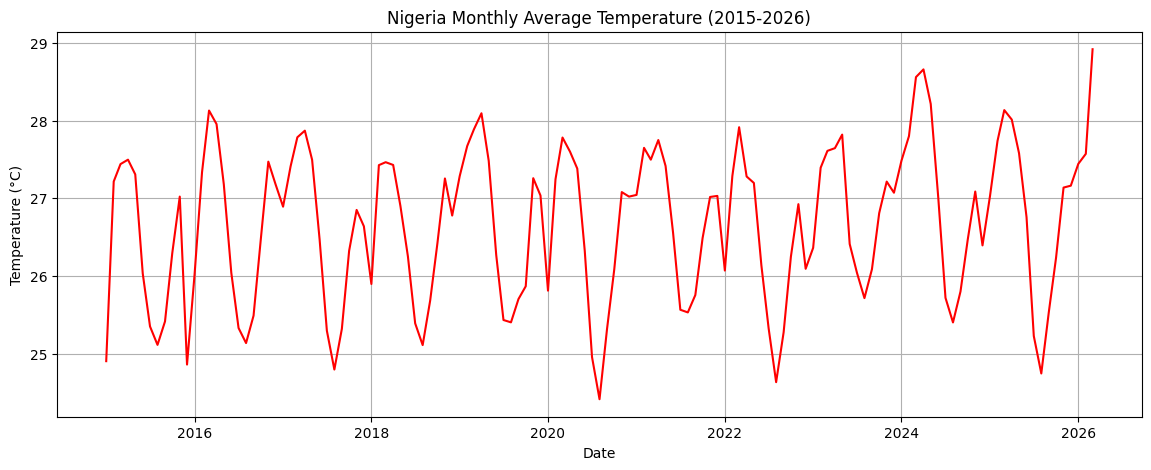

In [10]:
monthly = df.groupby(['Year','Month'])['T2M'].mean().reset_index()
monthly['Date'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str))
plt.figure(figsize=(14,5))
plt.plot(monthly['Date'], monthly['T2M'], color='red')
plt.title('Nigeria Monthly Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

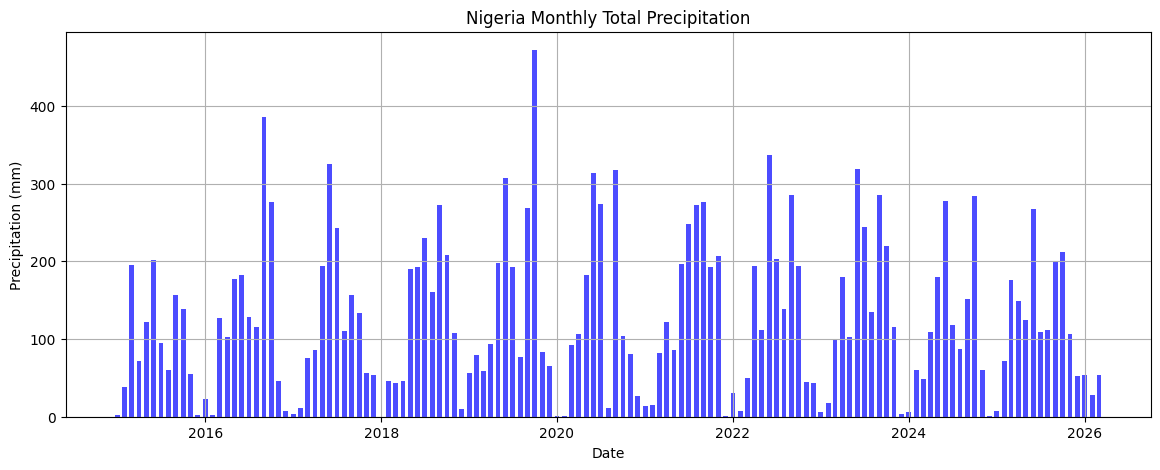

In [11]:
precip = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
precip['Date'] = pd.to_datetime(precip['Year'].astype(str) + '-' + precip['Month'].astype(str))
plt.figure(figsize=(14,5))
plt.bar(precip['Date'], precip['PRECTOTCORR'], width=20, color='blue', alpha=0.7)
plt.title('Nigeria Monthly Total Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.grid(True)
plt.show()

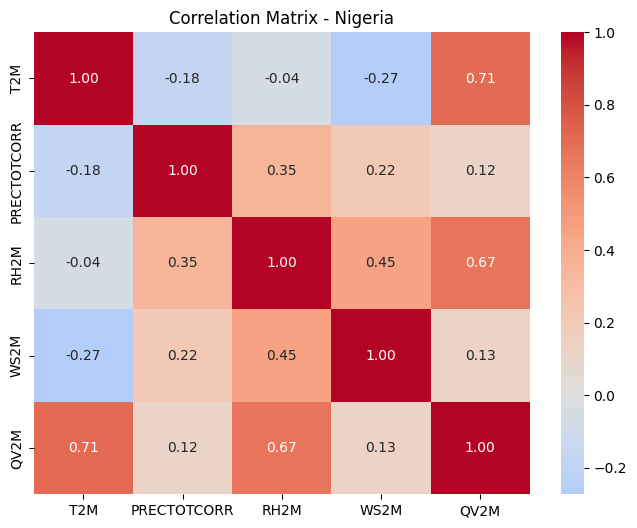

In [12]:
corr = df[['T2M','PRECTOTCORR','RH2M','WS2M','QV2M']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Nigeria')
plt.show()

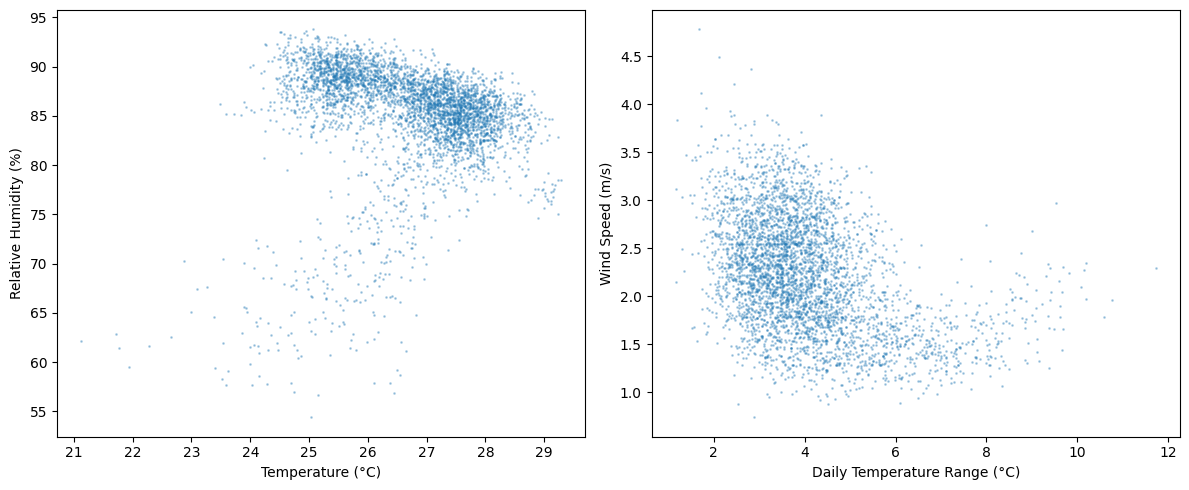

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
axes[1].set_xlabel('Daily Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
plt.tight_layout()
plt.show()

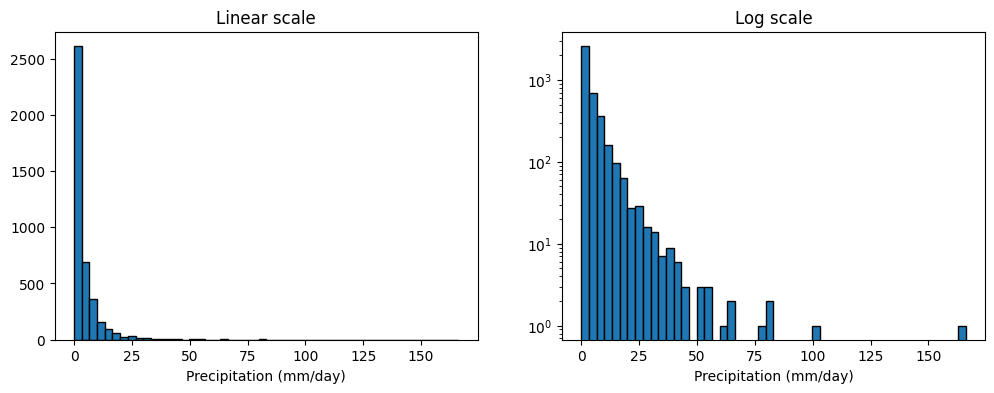

In [14]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[0].set_title('Linear scale')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[1].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Log scale')
axes[1].set_xlabel('Precipitation (mm/day)')
plt.show()

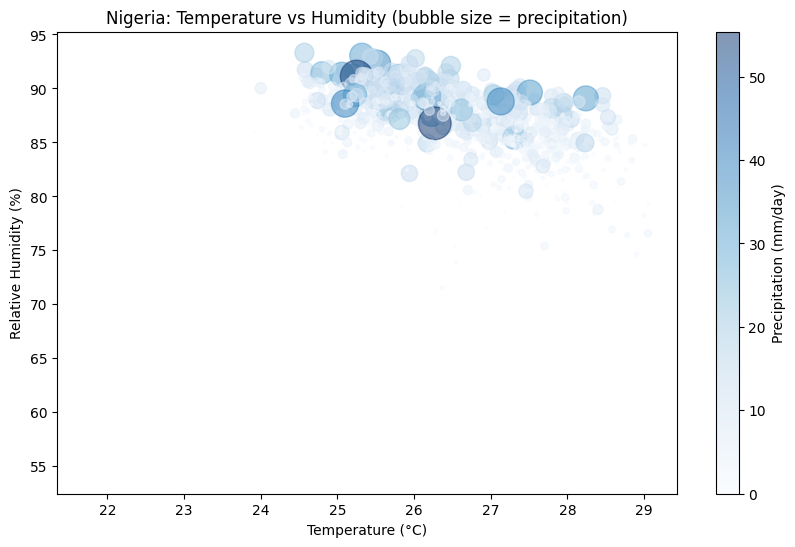

In [15]:
sample = df.sample(min(1000, len(df)))
plt.figure(figsize=(10,6))
sc = plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c=sample['PRECTOTCORR'], cmap='Blues')
plt.colorbar(sc, label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Nigeria: Temperature vs Humidity (bubble size = precipitation)')
plt.show()